In [4]:
import pandas as pd

df = pd.read_excel("../data/dataset.xlsx")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [6]:
df

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
...,...,...,...
1435,Excellent mobile,5,Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve..."
1437,Good value for money,5,Battery life is good but camera clarity could ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied....."


In [7]:
df

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
...,...,...,...
1435,Excellent mobile,5,Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve..."
1437,Good value for money,5,Battery life is good but camera clarity could ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied....."


In [8]:
df['rating'].value_counts()

rating
5    419
1    386
4    310
3    199
2    126
Name: count, dtype: int64

In [9]:
df[df['rating']==4]

,title,rating,body
2,Overall,4,"Got the mobile on the launch date,Battery must..."
34,Go For It,4,I am giving this review after usage of 2 daysI...
39,This is my honest opinion,4,Changing my review on this device after 2 mont...
59,Record sale good price good specs...,4,I have Mo2s and this m12....better buy m12 you...
62,Excellent Battery and budget,4,I have been using this phone for more than a w...
...,...,...,...
1415,Ok ok product,4,All ok . Superb.Only camera and screen display...
1419,Good but heavy,4,"Good but heavy, samsung has unmatched operatin..."
1422,Inbuilt apps lock not found,4,This product delivered by Amazon 21 march all...
1423,Good non Chinese phone.,4,Good phone for budget buyers. Sound quality is...


In [30]:
from sklearn.model_selection import train_test_split
X=df['body']
y=df['rating']

In [31]:
X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,test_size=0.2)

In [32]:
# Import required libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create pipeline
model = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=5000,
        ngram_range=(1, 2)
    )),
    ('lr', LogisticRegression(
        max_iter=1000,class_weight='balanced'
    ))
])

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.4722222222222222

Classification Report:
              precision    recall  f1-score   support

           1       0.66      0.64      0.65        77
           2       0.21      0.24      0.22        25
           3       0.31      0.30      0.30        40
           4       0.37      0.37      0.37        62
           5       0.55      0.55      0.55        84

    accuracy                           0.47       288
   macro avg       0.42      0.42      0.42       288
weighted avg       0.48      0.47      0.47       288


Confusion Matrix:
[[49 11 10  1  6]
 [ 8  6  8  3  0]
 [ 9  2 12 12  5]
 [ 3  5  5 23 26]
 [ 5  5  4 24 46]]


In [13]:
# Import required libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create the model pipeline
model = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=5000,
        ngram_range=(1, 2)
    )),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.46875

Classification Report:
              precision    recall  f1-score   support

           1       0.50      0.89      0.64        64
           2       0.00      0.00      0.00        20
           3       0.17      0.02      0.04        50
           4       0.36      0.08      0.13        65
           5       0.46      0.81      0.59        89

    accuracy                           0.47       288
   macro avg       0.30      0.36      0.28       288
weighted avg       0.37      0.47      0.36       288


Confusion Matrix:
[[57  0  1  2  4]
 [12  0  1  1  6]
 [23  0  1  3 23]
 [ 7  0  3  5 50]
 [14  0  0  3 72]]


c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [14]:
new_review = ["This product is amazing and I really love it"]

prediction = model.predict(new_review)

print("Predicted Rating:", prediction[0])

Predicted Rating: 1


In [15]:
# Import required libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create SVM model pipeline
model = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=5000,
        ngram_range=(1, 2)
    )),
    ('svm', SVC(
        kernel='linear',
        C=1.0
    ))
])

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.4895833333333333

Classification Report:
              precision    recall  f1-score   support

           1       0.57      0.83      0.68        64
           2       0.50      0.05      0.09        20
           3       0.33      0.18      0.23        50
           4       0.33      0.31      0.32        65
           5       0.55      0.65      0.60        89

    accuracy                           0.49       288
   macro avg       0.46      0.40      0.38       288
weighted avg       0.46      0.49      0.45       288


Confusion Matrix:
[[53  1  6  4  0]
 [ 9  1  5  2  3]
 [16  0  9 13 12]
 [ 9  0  4 20 32]
 [ 6  0  3 22 58]]


In [16]:
df['rating'].value_counts()

rating
5    419
1    386
4    310
3    199
2    126
Name: count, dtype: int64

In [17]:
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical


# -----------------------------
# 1. Prepare data
# -----------------------------

X = df['body'].astype(str)
y = df['rating']

# Encode ratings
# Example: 1,2,3,4,5 -> 0,1,2,3,4
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


# -----------------------------
# 2. Tokenization
# -----------------------------

max_words = 10000
max_length = 100

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)


# -----------------------------
# 3. Convert labels to categorical
# -----------------------------

y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)


# -----------------------------
# 4. Build LSTM model
# -----------------------------

model = Sequential([
    
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_length
    ),
    
    LSTM(64),
    
    Dropout(0.5),
    
    Dense(32, activation='relu'),
    
    Dense(5, activation='softmax')
])


# -----------------------------
# 5. Compile model
# -----------------------------

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# -----------------------------
# 6. Train model
# -----------------------------

history = model.fit(
    X_train_padded,
    y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)


# -----------------------------
# 7. Predictions
# -----------------------------

y_pred_prob = model.predict(X_test_padded)

y_pred = np.argmax(y_pred_prob, axis=1)


# -----------------------------
# 8. Evaluation
# -----------------------------

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[str(x) for x in label_encoder.classes_]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.2714 - loss: 1.5561 - val_accuracy: 0.2424 - val_loss: 1.5477
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.2649 - loss: 1.5348 - val_accuracy: 0.3247 - val_loss: 1.5429
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.2801 - loss: 1.5349 - val_accuracy: 0.3247 - val_loss: 1.5405
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.2704 - loss: 1.5321 - val_accuracy: 0.2511 - val_loss: 1.5406
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.2997 - loss: 1.5316 - val_accuracy: 0.2511 - val_loss: 1.5382
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.2986 - loss: 1.5225 - val_accuracy: 0.2468 - val_loss: 1.5399
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.2921 - loss: 1.5189 - val_accuracy: 0.2381 - val_loss: 1.5369
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.3431 - loss: 1.5085 - val_accuracy: 0.3117 - v

c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [18]:
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout


# -----------------------------
# 1. Prepare Data
# -----------------------------

X = df['body'].fillna('').astype(str)
y = df['rating']

# Convert ratings: 1,2,3,4,5 -> 0,1,2,3,4
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


# -----------------------------
# 2. Tokenization
# -----------------------------

max_words = 5000
max_length = 100

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

# Learn vocabulary only from training data
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Make all sequences the same length
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)


# -----------------------------
# 3. Build Simple RNN Model
# -----------------------------

model = Sequential([
    
    Embedding(
        input_dim=max_words,
        output_dim=32
    ),
    
    SimpleRNN(32),
    
    Dropout(0.3),
    
    Dense(16, activation='relu'),
    
    Dense(5, activation='softmax')
])


# -----------------------------
# 4. Compile Model
# -----------------------------

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# -----------------------------
# 5. Train Model
# -----------------------------

history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)


# -----------------------------
# 6. Make Predictions
# -----------------------------

y_pred_prob = model.predict(X_test_pad)

# Get class with highest probability
y_pred = np.argmax(y_pred_prob, axis=1)


# -----------------------------
# 7. Evaluate Model
# -----------------------------

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[str(x) for x in label_encoder.classes_],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.2410 - loss: 1.5752 - val_accuracy: 0.2381 - val_loss: 1.5516
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3116 - loss: 1.5222 - val_accuracy: 0.2814 - val_loss: 1.5571
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3713 - loss: 1.4667 - val_accuracy: 0.2987 - val_loss: 1.5580
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3855 - loss: 1.4476 - val_accuracy: 0.3203 - val_loss: 1.5515
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4615 - loss: 1.3677 - val_accuracy: 0.3030 - val_loss: 1.6018
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4376 - loss: 1.3310 - val_accuracy: 0.3463 - val_loss: 1.5773
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5429 - loss: 1.1517 - val_accuracy: 0.3377 - val_loss: 1.6668
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5874 - loss: 1.0193 - val_accuracy: 0.2987 - v

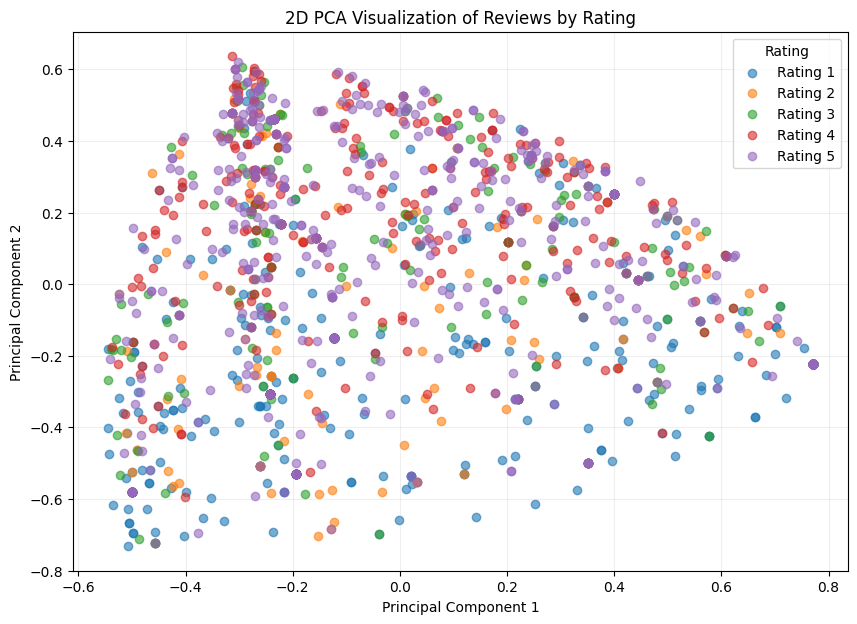

Explained variance ratio:
[0.2021113  0.17060843]

Total variance explained by 2 components: 0.37271973203699293


In [19]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# -----------------------------
# 1. Prepare data
# -----------------------------

texts = df['body'].fillna('').astype(str)
ratings = df['rating']


# -----------------------------
# 2. Convert text to TF-IDF
# -----------------------------

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=10,
    ngram_range=(1, 2),
    min_df=2
)

X_tfidf = vectorizer.fit_transform(texts)


# -----------------------------
# 3. PCA → 2 dimensions
# -----------------------------

# PCA needs dense data
X_dense = X_tfidf.toarray()

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_dense)


# -----------------------------
# 4. Plot
# -----------------------------

plt.figure(figsize=(10, 7))

for rating in sorted(ratings.unique()):

    mask = ratings.values == rating

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f'Rating {rating}',
        alpha=0.6
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA Visualization of Reviews by Rating')

plt.legend(title='Rating')
plt.grid(alpha=0.2)

plt.show()


# -----------------------------
# 5. Explained variance
# -----------------------------

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "\nTotal variance explained by 2 components:",
    pca.explained_variance_ratio_.sum()
)

In [24]:
# Import required libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create KNN model pipeline
model = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=5000,
        ngram_range=(1, 2)
    )),
    ('knn', KNeighborsClassifier(
        n_neighbors=10,
        metric='cosine',
        algorithm='brute'
    ))
])

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.4618055555555556

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.78      0.69        77
           1       0.17      0.04      0.06        25
           2       0.28      0.12      0.17        40
           3       0.31      0.34      0.32        62
           4       0.47      0.55      0.51        84

    accuracy                           0.46       288
   macro avg       0.37      0.37      0.35       288
weighted avg       0.42      0.46      0.43       288


Confusion Matrix:
[[60  0  1  8  8]
 [10  1  3  6  5]
 [15  3  5  8  9]
 [ 7  0  4 21 30]
 [ 6  2  5 25 46]]


In [25]:
# Import required libraries
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Bag of Words + KNN model pipeline
model = Pipeline([
    ('bow', CountVectorizer(
        stop_words='english',
        max_features=5000,
        ngram_range=(1, 2)
    )),
    ('knn', KNeighborsClassifier(
        n_neighbors=5,
        metric='cosine',
        algorithm='brute'
    ))
])

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.3958333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.66      0.60        77
           1       0.15      0.08      0.11        25
           2       0.18      0.07      0.11        40
           3       0.30      0.34      0.32        62
           4       0.40      0.44      0.42        84

    accuracy                           0.40       288
   macro avg       0.31      0.32      0.31       288
weighted avg       0.36      0.40      0.37       288


Confusion Matrix:
[[51  4  4  6 12]
 [11  2  3  5  4]
 [15  4  3  8 10]
 [ 5  1  5 21 30]
 [12  2  2 31 37]]


In [35]:
# Import required libraries
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Bag of Words + Random Forest model pipeline
model = Pipeline([
    ('bow', CountVectorizer(
        stop_words='english',
        max_features=10000,
        ngram_range=(1, 2)
    )),
    ('rf', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.4826388888888889

Classification Report:
              precision    recall  f1-score   support

           1       0.57      0.77      0.66        77
           2       0.00      0.00      0.00        25
           3       0.40      0.05      0.09        40
           4       0.50      0.08      0.14        62
           5       0.43      0.87      0.57        84

    accuracy                           0.48       288
   macro avg       0.38      0.35      0.29       288
weighted avg       0.44      0.48      0.39       288


Confusion Matrix:
[[59  0  1  0 17]
 [14  0  2  1  8]
 [14  0  2  2 22]
 [ 7  0  0  5 50]
 [ 9  0  0  2 73]]


c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

model = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        ngram_range=(1, 2),
        max_features=20000,
        min_df=2
    )),
    ('nb', MultinomialNB(alpha=0.5))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5104166666666666
              precision    recall  f1-score   support

           1       0.63      0.81      0.70        77
           2       0.00      0.00      0.00        25
           3       0.00      0.00      0.00        40
           4       0.32      0.16      0.22        62
           5       0.47      0.89      0.62        84

    accuracy                           0.51       288
   macro avg       0.28      0.37      0.31       288
weighted avg       0.38      0.51      0.42       288



c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [33]:
# Import libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Encode labels
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Convert text into sequences
max_words = 10000
max_length = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Make all sequences the same length
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post'
)

# Number of classes
num_classes = len(np.unique(y_train_encoded))

# Build Simple RNN model
model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=64,
        input_length=max_length
    ),
    SimpleRNN(64),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train_pad,
    y_train_encoded,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

# Make predictions
y_prob = model.predict(X_test_pad)
y_pred_encoded = np.argmax(y_prob, axis=1)

# Convert predictions back to original labels
y_pred = label_encoder.inverse_transform(y_pred_encoded)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Epoch 1/10


c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.2823 - loss: 1.5646 - val_accuracy: 0.3420 - val_loss: 1.4892
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2932 - loss: 1.5498 - val_accuracy: 0.3723 - val_loss: 1.5240
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2932 - loss: 1.5481 - val_accuracy: 0.3290 - val_loss: 1.5046
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3355 - loss: 1.5238 - val_accuracy: 0.2684 - val_loss: 1.5134
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3420 - loss: 1.5009 - val_accuracy: 0.2857 - val_loss: 1.5184
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3757 - loss: 1.4416 - val_accuracy: 0.3377 - val_loss: 1.5121
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4864 - loss: 1.3370 - val_accuracy: 0.2684 - val_loss: 1.5872
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6080 - loss: 1.0776 - val_accuracy: 0.3117 - val_loss: 1.

In [45]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create sentiment labels from rating
def sentiment_label(x):
    if x >= 4:
        return "Positive"
    elif x == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['rating'].apply(sentiment_label)

# Check class distribution
print(df['sentiment'].value_counts())

# Remove missing values
data = df[['body', 'sentiment']].dropna()

# Select text and target columns
X = data['body']
y = data['sentiment']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create TF-IDF + SVC pipeline
model = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=5000,
        ngram_range=(1, 2)
    )),
    ('svc', SVC(
        kernel='linear',
        C=1.0,
        class_weight='balanced',
        random_state=42
    ))
])

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64

Accuracy: 0.7395833333333334

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.81      0.78       102
     Neutral       0.28      0.20      0.23        40
    Positive       0.82      0.84      0.83       146

    accuracy                           0.74       288
   macro avg       0.62      0.62      0.61       288
weighted avg       0.72      0.74      0.73       288


Confusion Matrix:
[[ 83   8  11]
 [ 16   8  16]
 [ 11  13 122]]


In [47]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create sentiment labels from rating
def sentiment_label(x):
    if x >= 4:
        return "Positive"
    elif x == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['rating'].apply(sentiment_label)

# Check class distribution
print(df['sentiment'].value_counts())

# Select text and target columns
X = df['body']       # Change 'text' to your actual review column name if needed
y = df['sentiment']

# Remove missing values
data = df[['body', 'sentiment']].dropna()

X = data['body']
y = data['sentiment']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create TF-IDF + Random Forest pipeline
model = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=5000,
        ngram_range=(1, 2)
    )),
    ('rf', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))




sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64

Accuracy: 0.7291666666666666

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.71      0.73       102
     Neutral       1.00      0.03      0.05        40
    Positive       0.72      0.94      0.81       146

    accuracy                           0.73       288
   macro avg       0.82      0.56      0.53       288
weighted avg       0.77      0.73      0.68       288


Confusion Matrix:
[[ 72   0  30]
 [ 15   1  24]
 [  9   0 137]]


In [51]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler

# Create sentiment labels
def sentiment_label(x):
    if x >= 4:
        return "Positive"
    elif x == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['rating'].apply(sentiment_label)

# Remove missing values
data = df[['body', 'sentiment']].dropna()

X = data['body']
y = data['sentiment']

# Split the dataset first
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert text to TF-IDF features
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Apply Random Oversampling ONLY to training data
oversampler = RandomOverSampler(random_state=42)

X_train_resampled, y_train_resampled = oversampler.fit_resample(
    X_train_tfidf,
    y_train
)

# Check class distribution after balancing
print("\nBefore Oversampling:")
print(y_train.value_counts())

print("\nAfter Oversampling:")
print(y_train_resampled.value_counts())

# Create SVC model
model = SVC(
    kernel='linear',
    C=1.0,
    random_state=42
)

# Train the model on balanced data
model.fit(X_train_resampled, y_train_resampled)

# Make predictions
y_pred = model.predict(X_test_tfidf)

# Evaluate the model
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Before Oversampling:
sentiment
Positive    583
Negative    410
Neutral     159
Name: count, dtype: int64

After Oversampling:
sentiment
Positive    583
Negative    583
Neutral     583
Name: count, dtype: int64

Accuracy: 0.7708333333333334

Classification Report:
              precision    recall  f1-score   support

    Negative       0.76      0.82      0.79       102
     Neutral       0.43      0.15      0.22        40
    Positive       0.81      0.90      0.85       146

    accuracy                           0.77       288
   macro avg       0.67      0.63      0.62       288
weighted avg       0.74      0.77      0.74       288


Confusion Matrix:
[[ 84   5  13]
 [ 16   6  18]
 [ 11   3 132]]


In [50]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create sentiment labels from rating
def sentiment_label(x):
    if x >= 4:
        return "Positive"
    elif x == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['rating'].apply(sentiment_label)

# Check class distribution
print(df['sentiment'].value_counts())

# Remove missing values
data = df[['body', 'sentiment']].dropna()

# Select text and target columns
X = data['body']
y = data['sentiment']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create TF-IDF + SVC pipeline
model = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=10000,
        ngram_range=(1, 2)
    )),
    ('svc', SVC(
        kernel='linear',
        C=1.0,
        class_weight='balanced',
        random_state=42
    ))
])

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64

Accuracy: 0.75

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.82      0.80       102
     Neutral       0.27      0.15      0.19        40
    Positive       0.80      0.86      0.83       146

    accuracy                           0.75       288
   macro avg       0.62      0.61      0.61       288
weighted avg       0.72      0.75      0.73       288


Confusion Matrix:
[[ 84   6  12]
 [ 15   6  19]
 [ 10  10 126]]


In [40]:
# Import required libraries
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Create sentiment labels
def sentiment_label(x):
    if x >= 4:
        return "Positive"
    elif x == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['rating'].apply(sentiment_label)

# Select text and sentiment columns
data = df[['body', 'sentiment']].dropna()  # Change 'text' if needed

X = data['body'].astype(str)
y = data['sentiment']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert sentiment labels to numbers
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Convert text to sequences
max_words = 10000
max_length = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post'
)

# Build Simple RNN model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=32),
    SimpleRNN(12),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')  # 3 sentiment classes
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
model.fit(
    X_train_pad,
    y_train_encoded,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

# Make predictions
y_prob = model.predict(X_test_pad)
y_pred_encoded = np.argmax(y_prob, axis=1)

# Convert predictions back to sentiment labels
y_pred = label_encoder.inverse_transform(y_pred_encoded)

# Evaluate the model
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.3116 - loss: 1.0940 - val_accuracy: 0.3420 - val_loss: 1.0624
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4235 - loss: 1.0245 - val_accuracy: 0.4242 - val_loss: 1.0119
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5972 - loss: 0.9312 - val_accuracy: 0.4805 - val_loss: 0.9782
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7644 - loss: 0.7768 - val_accuracy: 0.5411 - val_loss: 0.9801
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8610 - loss: 0.5714 - val_accuracy: 0.5065 - val_loss: 1.0018
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9001 - loss: 0.3900 - val_accuracy: 0.4848 - val_loss: 1.1086
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9425 - loss: 0.2500 - val_accuracy: 0.4632 - val_loss: 1.2733
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9620 - loss: 0.1841 - val_accuracy: 0.4589 - v

In [42]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create sentiment labels
def sentiment_label(x):
    if x >= 4:
        return "Positive"
    elif x == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['rating'].apply(sentiment_label)

# Remove missing values
data = df[['body', 'sentiment']].dropna()  # Change 'text' if needed

# Select input and target
X = data['body'].astype(str)
y = data['sentiment']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create TF-IDF + Naive Bayes pipeline
model = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=10000,
        ngram_range=(1, 2)
    )),
    ('nb', MultinomialNB(alpha=1.0))
])

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7083333333333334

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.60      0.69       102
     Neutral       0.00      0.00      0.00        40
    Positive       0.67      0.98      0.80       146

    accuracy                           0.71       288
   macro avg       0.49      0.53      0.49       288
weighted avg       0.63      0.71      0.65       288


Confusion Matrix:
[[ 61   0  41]
 [ 12   0  28]
 [  3   0 143]]


c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [55]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler

# Create sentiment labels
def sentiment_label(x):
    if x >= 4:
        return "Positive"
    elif x == 3:
        return "Neutral"
    else:
        return "Negative"


# Create sentiment column
df["sentiment"] = df["rating"].apply(sentiment_label)

# Remove missing values
data = df[["body", "sentiment"]].dropna()

# Input and target
X = data["body"].astype(str)
y = data["sentiment"]

# Split data FIRST to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert text to TF-IDF features
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Check class distribution before oversampling
print("Before Oversampling:")
print(y_train.value_counts())

# Apply Random Oversampling ONLY to training data
oversampler = RandomOverSampler(random_state=42)

X_train_resampled, y_train_resampled = oversampler.fit_resample(
    X_train_tfidf,
    y_train
)

# Check class distribution after oversampling
print("\nAfter Oversampling:")
print(y_train_resampled.value_counts())

# Create Random Forest model
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train model on oversampled data
model.fit(X_train_resampled, y_train_resampled)

# Make predictions on original test data
y_pred = model.predict(X_test_tfidf)

# Evaluate model
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Before Oversampling:
sentiment
Positive    583
Negative    410
Neutral     159
Name: count, dtype: int64

After Oversampling:
sentiment
Positive    583
Negative    583
Neutral     583
Name: count, dtype: int64

Accuracy: 0.7395833333333334

Classification Report:
              precision    recall  f1-score   support

    Negative       0.73      0.75      0.74       102
     Neutral       1.00      0.05      0.10        40
    Positive       0.74      0.92      0.82       146

    accuracy                           0.74       288
   macro avg       0.82      0.57      0.55       288
weighted avg       0.77      0.74      0.69       288


Confusion Matrix:
[[ 76   0  26]
 [ 17   2  21]
 [ 11   0 135]]


In [56]:
# Import required libraries
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import RandomOverSampler

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense


# Create sentiment labels
def sentiment_label(x):
    if x >= 4:
        return "Positive"
    elif x == 3:
        return "Neutral"
    else:
        return "Negative"


# Create sentiment column
df["sentiment"] = df["rating"].apply(sentiment_label)

# Remove missing values
data = df[["body", "sentiment"]].dropna()

# Input and target
X = data["body"].astype(str)
y = data["sentiment"]


# Split the data FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Check class distribution before oversampling
print("Before Oversampling:")
print(y_train.value_counts())


# Oversampling
# Convert X_train to 2D because RandomOverSampler requires 2D input
X_train_array = np.array(X_train).reshape(-1, 1)

oversampler = RandomOverSampler(random_state=42)

X_train_resampled, y_train_resampled = oversampler.fit_resample(
    X_train_array,
    y_train
)

# Convert back to 1D text array
X_train_resampled = X_train_resampled.ravel()


# Check class distribution after oversampling
print("\nAfter Oversampling:")
print(y_train_resampled.value_counts())


# Encode sentiment labels
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train_resampled)
y_test_encoded = label_encoder.transform(y_test)


# Tokenizer settings
max_words = 10000
max_length = 100

tokenizer = Tokenizer(num_words=max_words)

# Fit tokenizer on oversampled training text
tokenizer.fit_on_texts(X_train_resampled)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_resampled)
X_test_seq = tokenizer.texts_to_sequences(X_test)


# Pad sequences
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post"
)


# Number of classes
num_classes = len(label_encoder.classes_)


# Build Simple RNN model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=32),
    SimpleRNN(32),
    Dense(16, activation="relu"),
    Dense(num_classes, activation="softmax")
])


# Compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# Train the model
model.fit(
    X_train_pad,
    y_train_encoded,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)


# Make predictions
y_prob = model.predict(X_test_pad)

y_pred_encoded = np.argmax(y_prob, axis=1)

# Convert predictions back to sentiment labels
y_pred = label_encoder.inverse_transform(y_pred_encoded)


# Evaluate model
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Before Oversampling:
sentiment
Positive    583
Negative    410
Neutral     159
Name: count, dtype: int64

After Oversampling:
sentiment
Positive    583
Negative    583
Neutral     583
Name: count, dtype: int64
Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.4382 - loss: 1.0357 - val_accuracy: 0.0314 - val_loss: 1.5183
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6240 - loss: 0.8996 - val_accuracy: 0.0657 - val_loss: 1.5926
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7684 - loss: 0.6474 - val_accuracy: 0.4943 - val_loss: 1.1537
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8978 - loss: 0.3795 - val_accuracy: 0.7000 - val_loss: 0.7696
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9521 - loss: 0.1944 - val_accuracy: 0.8914 - val_loss: 0.3243
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9771 - loss: 0.1021 - val_accuracy: 0.9457 - val_loss: 0.2082
Epoch 7/10
44/44 ━━━━━━━━━━━

In [57]:
# Evaluate model
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.4548611111111111

Classification Report:
              precision    recall  f1-score   support

    Negative       0.43      0.41      0.42       102
     Neutral       0.17      0.17      0.17        40
    Positive       0.55      0.56      0.56       146

    accuracy                           0.45       288
   macro avg       0.38      0.38      0.38       288
weighted avg       0.46      0.45      0.46       288


Confusion Matrix:
[[42 15 45]
 [12  7 21]
 [44 20 82]]


In [58]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler

# Create sentiment labels
def sentiment_label(x):
    if x >= 4:
        return "Positive"
    elif x == 3:
        return "Neutral"
    else:
        return "Negative"


# Create sentiment column
df["sentiment"] = df["rating"].apply(sentiment_label)

# Remove missing values
data = df[["body", "sentiment"]].dropna()

# Input and target
X = data["body"].astype(str)
y = data["sentiment"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert text to TF-IDF features
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Class distribution before oversampling
print("Before Oversampling:")
print(y_train.value_counts())

# Apply Random Oversampling to TRAINING data only
oversampler = RandomOverSampler(random_state=42)

X_train_resampled, y_train_resampled = oversampler.fit_resample(
    X_train_tfidf,
    y_train
)

# Class distribution after oversampling
print("\nAfter Oversampling:")
print(y_train_resampled.value_counts())

# Create Multinomial Naive Bayes model
model = MultinomialNB(alpha=1.0)

# Train the model
model.fit(X_train_resampled, y_train_resampled)

# Make predictions
y_pred = model.predict(X_test_tfidf)

# Evaluate the model
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Before Oversampling:
sentiment
Positive    583
Negative    410
Neutral     159
Name: count, dtype: int64

After Oversampling:
sentiment
Positive    583
Negative    583
Neutral     583
Name: count, dtype: int64

Accuracy: 0.7083333333333334

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.77      0.77       102
     Neutral       0.28      0.33      0.30        40
    Positive       0.81      0.77      0.79       146

    accuracy                           0.71       288
   macro avg       0.62      0.62      0.62       288
weighted avg       0.72      0.71      0.71       288


Confusion Matrix:
[[ 79  10  13]
 [ 13  13  14]
 [ 10  24 112]]


In [59]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Create sentiment labels
def sentiment_label(x):
    if x >= 4:
        return "Positive"
    elif x == 3:
        return "Neutral"
    else:
        return "Negative"


# Create sentiment column
df["sentiment"] = df["rating"].apply(sentiment_label)

# Remove missing values
data = df[["body", "sentiment"]].dropna()

# Input and target
X = data["body"].astype(str)
y = data["sentiment"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Check distribution before SMOTE
print("Before SMOTE:")
print(y_train.value_counts())

# Apply SMOTE only to training data
smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_tfidf,
    y_train
)

# Check distribution after SMOTE
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

# Create Random Forest model
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train the model
model.fit(X_train_smote, y_train_smote)

# Make predictions
y_pred = model.predict(X_test_tfidf)

# Evaluate the model
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Before SMOTE:
sentiment
Positive    583
Negative    410
Neutral     159
Name: count, dtype: int64

After SMOTE:
sentiment
Positive    583
Negative    583
Neutral     583
Name: count, dtype: int64

Accuracy: 0.7326388888888888

Classification Report:
              precision    recall  f1-score   support

    Negative       0.73      0.75      0.74       102
     Neutral       0.60      0.07      0.13        40
    Positive       0.74      0.90      0.81       146

    accuracy                           0.73       288
   macro avg       0.69      0.58      0.56       288
weighted avg       0.72      0.73      0.69       288


Confusion Matrix:
[[ 77   0  25]
 [ 16   3  21]
 [ 13   2 131]]


In [60]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create sentiment labels
def sentiment_label(x):
    if x >= 4:
        return "Positive"
    elif x == 3:
        return "Neutral"
    else:
        return "Negative"


df["sentiment"] = df["rating"].apply(sentiment_label)

# Remove missing values
data = df[["body", "sentiment"]].dropna()

X = data["body"].astype(str)
y = data["sentiment"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF
tfidf = TfidfVectorizer(
    lowercase=True,
    max_features=20000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Linear SVM
model = LinearSVC(
    C=0.5,
    class_weight="balanced"
)

# Train
model.fit(X_train_tfidf, y_train)

# Predict
y_pred = model.predict(X_test_tfidf)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7673611111111112

Classification Report:
              precision    recall  f1-score   support

    Negative       0.76      0.83      0.79       102
     Neutral       0.21      0.07      0.11        40
    Positive       0.82      0.91      0.86       146

    accuracy                           0.77       288
   macro avg       0.60      0.61      0.59       288
weighted avg       0.71      0.77      0.73       288


Confusion Matrix:
[[ 85   6  11]
 [ 19   3  18]
 [  8   5 133]]


In [67]:
# Import required libraries
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# --------------------------------------------------
# 1. Create sentiment labels
# --------------------------------------------------

def sentiment_label(x):
    if x >= 4:
        return "Positive"
    elif x == 3:
        return "Neutral"
    else:
        return "Negative"


df["sentiment"] = df["rating"].apply(sentiment_label)


# --------------------------------------------------
# 2. Remove missing values
# --------------------------------------------------

data = df[["body", "sentiment"]].dropna()

X = data["body"].astype(str)
y = data["sentiment"]


# --------------------------------------------------
# 3. Split data
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# --------------------------------------------------
# 4. Encode labels
# --------------------------------------------------

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)


# --------------------------------------------------
# 5. Tokenize text
# --------------------------------------------------

max_words = 10000
max_length = 100

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)


# --------------------------------------------------
# 6. Pad sequences
# --------------------------------------------------

X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)


# --------------------------------------------------
# 7. Build Simple RNN model
# --------------------------------------------------

num_classes = len(label_encoder.classes_)

model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=128
    ),

    SimpleRNN(
        12,
        return_sequences=True
    ),
    SimpleRNN(
        12,
    ),


    Dense(
        num_classes,
        activation="softmax"
    )
])


# --------------------------------------------------
# 8. Compile model
# --------------------------------------------------

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# --------------------------------------------------
# 9. Early stopping
# --------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


# --------------------------------------------------
# 10. Train model
# --------------------------------------------------

history = model.fit(
    X_train_padded,
    y_train_encoded,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)


# --------------------------------------------------
# 11. Make predictions
# --------------------------------------------------

y_prob = model.predict(X_test_padded)

y_pred_encoded = np.argmax(y_prob, axis=1)


# --------------------------------------------------
# 12. Convert predictions back to labels
# --------------------------------------------------

y_pred = label_encoder.inverse_transform(
    y_pred_encoded
)


# --------------------------------------------------
# 13. Evaluate model
# --------------------------------------------------

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classes: ['Negative' 'Neutral' 'Positive']
Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.4256 - loss: 1.0166 - val_accuracy: 0.5281 - val_loss: 0.9692
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5570 - loss: 0.9384 - val_accuracy: 0.5022 - val_loss: 0.9783
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5917 - loss: 0.8837 - val_accuracy: 0.5022 - val_loss: 0.9879
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7166 - loss: 0.7376 - val_accuracy: 0.4545 - val_loss: 1.0628
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Accuracy: 0.5034722222222222

Classification Report:
              precision    recall  f1-score   support

    Negative       0.43      0.03      0.06       102
     Neutral       0.00      0.00      0.00        40
    Positive       0.51      0.97      0.67       146

    accuracy                           0.50       288
   macro avg       0.31      0.33      0.24       288
weighted avg       0.41      0.

c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [ ]:
# ============================================================
# COMPLETE UPDATED SENTIMENT ANALYSIS CODE - RANDOM FOREST
# Includes:
# 1. Sentiment label creation
# 2. Missing value removal
# 3. Text cleaning
# 4. Duplicate removal
# 5. Train-test split
# 6. TF-IDF feature extraction
# 7. Random Forest with class balancing
# 8. Hyperparameter tuning
# 9. Model evaluation
# ============================================================


# -----------------------------
# 1. Import required libraries
# -----------------------------

import re
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# -----------------------------
# 2. Create sentiment labels
# -----------------------------

def sentiment_label(x):
    if x >= 4:
        return "Positive"
    elif x == 3:
        return "Neutral"
    else:
        return "Negative"


df["sentiment"] = df["rating"].apply(sentiment_label)


# -----------------------------
# 3. Select required columns
# -----------------------------

data = df[["body", "sentiment"]].copy()


# -----------------------------
# 4. Remove missing values
# -----------------------------

data = data.dropna(subset=["body", "sentiment"])

# Convert text to string
data["body"] = data["body"].astype(str)


# -----------------------------
# 5. Clean text
# -----------------------------

def clean_text(text):
    
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)
    
    # Keep letters and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


data["clean_body"] = data["body"].apply(clean_text)


# -----------------------------
# 6. Remove empty reviews
# -----------------------------

data = data[data["clean_body"] != ""]


# -----------------------------
# 7. Remove duplicate reviews
# -----------------------------

print("Duplicate reviews before removal:",
      data.duplicated(subset=["clean_body"]).sum())

data = data.drop_duplicates(
    subset=["clean_body"],
    keep="first"
)

print("Dataset shape after cleaning:", data.shape)


# -----------------------------
# 8. Check class distribution
# -----------------------------

print("\nClass Distribution:")
print(data["sentiment"].value_counts())


# -----------------------------
# 9. Check conflicting labels
# -----------------------------

conflicts = (
    data.groupby("clean_body")["sentiment"]
    .nunique()
)

conflicting_reviews = conflicts[conflicts > 1]

print("\nConflicting reviews:",
      len(conflicting_reviews))


# -----------------------------
# 10. Input and target
# -----------------------------

X = data["clean_body"]
y = data["sentiment"]


# -----------------------------
# 11. Train-test split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())


# ============================================================
# 12. Create TF-IDF + RANDOM FOREST PIPELINE
# ============================================================

pipeline = Pipeline([

    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            sublinear_tf=True
        )
    ),

    (
        "rf",
        RandomForestClassifier(
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        )
    )
])


# ============================================================
# 13. Hyperparameter tuning
# ============================================================

param_grid = {

    # TF-IDF parameters
    "tfidf__max_features": [
        5000,
        10000,
        20000
    ],

    "tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],

    "tfidf__min_df": [
        1,
        2,
        3
    ],

    "tfidf__max_df": [
        0.90,
        0.95,
        1.0
    ],

    # Random Forest parameters
    "rf__n_estimators": [
        200,
        300,
        500
    ],

    "rf__max_depth": [
        None,
        20,
        40
    ],

    "rf__min_samples_split": [
        2,
        5
    ],

    "rf__min_samples_leaf": [
        1,
        2
    ],

    "rf__max_features": [
        "sqrt",
        "log2"
    ]
}


# ============================================================
# 14. Grid Search
# ============================================================

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)


# Train GridSearch
grid_search.fit(X_train, y_train)


# ============================================================
# 15. Display best parameters
# ============================================================

print("\n" + "=" * 60)
print("BEST PARAMETERS")
print("=" * 60)

print(grid_search.best_params_)


print("\nBest Cross-Validation Macro F1 Score:")
print(grid_search.best_score_)


# ============================================================
# 16. Get best model
# ============================================================

best_model = grid_search.best_estimator_


# ============================================================
# 17. Make predictions
# ============================================================

y_pred = best_model.predict(X_test)


# ============================================================
# 18. Evaluate model
# ============================================================

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))


print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)


print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

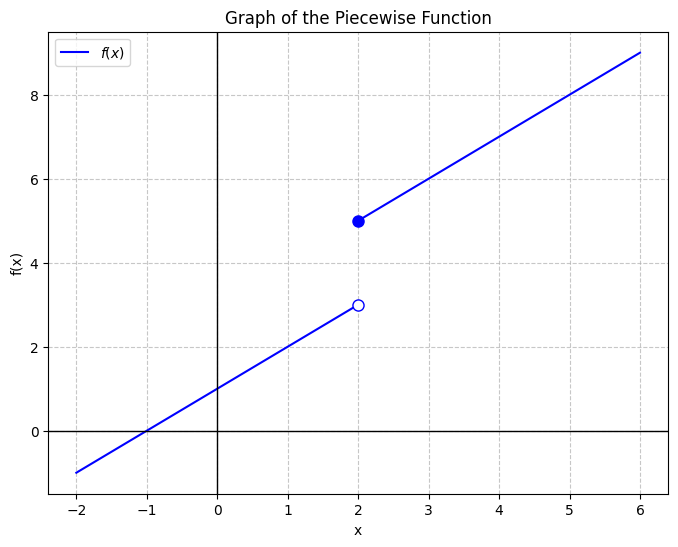

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Define the intervals for x
x_left = np.linspace(-2, 1.95, 100)  # Values less than 2
x_right = np.linspace(2.05, 6, 100)  # Values greater than 2

# Define the corresponding y values
y_left = x_left + 1
y_right = x_right + 3

plt.figure(figsize=(8, 6))

# Plot the lines
plt.plot(x_left, y_left, 'b-', label='$f(x)$')
plt.plot(x_right, y_right, 'b-')

# Plot the points at x = 2
plt.plot(2, 3, 'bo', markerfacecolor='white', markersize=8) # Open circle at (2, 3)
plt.plot(2, 5, 'bo', markersize=8)                          # Solid dot at (2, 5)

# Formatting the graph
plt.title('Graph of the Piecewise Function')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Display the plot
plt.show()